In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler , MinMaxScaler

<h1>1. Load data</h1>

In [21]:
df = pd.read_csv("C:/Users/El_AMIR TECH/Downloads/Original_Data.csv", encoding="latin1")

In [22]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [24]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [11]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column: {col}")
    print("Unique values:", df[col].unique())
    print("Count:", df[col].nunique())
    print("---------------")

Column: Order ID
Unique values: ['CA-2012-124891' 'IN-2013-77878' 'IN-2013-71249' ... 'IN-2014-72327'
 'IN-2014-57662' 'MX-2012-134460']
Count: 25035
---------------
Column: Order Date
Unique values: ['31-07-2012' '05-02-2013' '17-10-2013' ... '07-07-2013' '27-05-2012'
 '06-02-2011']
Count: 1430
---------------
Column: Ship Date
Unique values: ['31-07-2012' '07-02-2013' '18-10-2013' ... '23-07-2012' '08-04-2012'
 '05-01-2011']
Count: 1464
---------------
Column: Ship Mode
Unique values: ['Same Day' 'Second Class' 'First Class' 'Standard Class']
Count: 4
---------------
Column: Customer ID
Unique values: ['RH-19495' 'JR-16210' 'CR-12730' ... 'RC-9825' 'MG-7890' 'ZC-11910']
Count: 1590
---------------
Column: Customer Name
Unique values: ['Rick Hansen' 'Justin Ritter' 'Craig Reiter' 'Katherine Murray'
 'Jim Mitchum' 'Toby Swindell' 'Mick Brown' 'Jane Waco' 'Joseph Holt'
 'Greg Maxwell' 'Anthony Jacobs' 'Magdelene Morse' 'Vicky Freymann'
 'Peter Fuller' 'Ben Peterman' 'Thomas Boland' 'Pat

<h1>2. Drop unnecessary columns</h1>

In [30]:
df = df.drop(columns=["Postal Code", "Row ID", "Customer Name", "Customer ID", "Order ID" , "City" , "State"])
print("Columns after drop:", df.columns.tolist())

Columns after drop: ['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'Country', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


<h1>3. Outlier detection function (for multiple columns)</h1>

In [15]:
def detect_outliers_iqr_multi(data, columns):
    results = {}
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        results[col] = {
            "outliers_count": outliers.shape[0],
            "lower_bound": lower,
            "upper_bound": upper
        }
        print(f"\n{col} → Outliers: {outliers.shape[0]} | Range: {lower:.2f} - {upper:.2f}")
    return results

<h3>Detect outliers for Sales, Profit, Discount </h3>

In [16]:
outlier_results = detect_outliers_iqr_multi(df, ["Sales", "Profit", "Discount"])


Sales → Outliers: 5655 | Range: -299.68 - 581.50

Profit → Outliers: 9755 | Range: -55.22 - 92.03

Discount → Outliers: 4172 | Range: -0.30 - 0.50


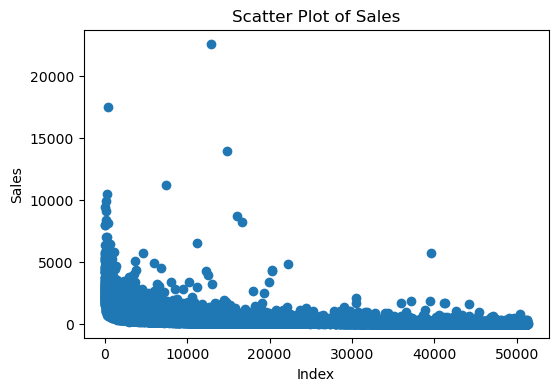

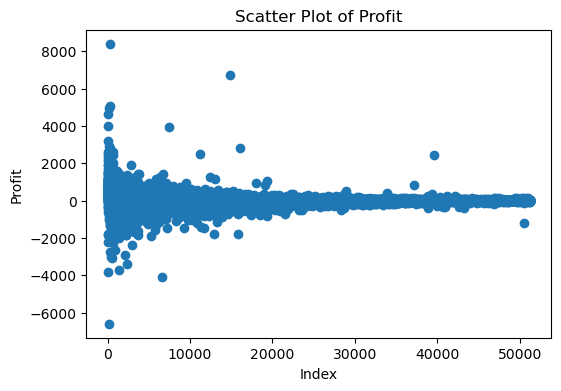

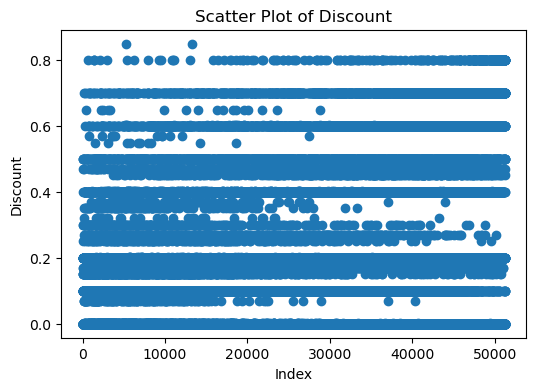

In [18]:
cols = ["Sales", "Profit", "Discount"]

for col in cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df.index, df[col])
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.title(f"Scatter Plot of {col}")
    plt.show()

<h1>4. Handle Discount, Sales and Profit outliers outliers</h1>

In [26]:
def cap_outliers_percentile(data, columns, lower_p=0.01, upper_p=0.99):
    df_clean = data.copy()
    for col in columns:

        lower_limit = df_clean[col].quantile(lower_p)
        upper_limit = df_clean[col].quantile(upper_p)
        
        print(f"{col} - Capping between: {lower_limit:.2f} and {upper_limit:.2f}")
        
        df_clean[col] = df_clean[col].clip(lower=lower_limit, upper=upper_limit)
        
    return df_clean

cols_to_fix = ['Sales', 'Profit']
df_fixed = cap_outliers_percentile(df, cols_to_fix)

Sales - Capping between: 3.69 and 2301.00
Profit - Capping between: -351.51 and 587.36


In [27]:
df_fixed = df_fixed[(df_fixed['Discount'] >= 0) & (df_fixed['Discount'] <= 1)]

              Sales        Profit      Discount
count  51290.000000  51290.000000  51290.000000
mean     235.416044     28.129258      0.142908
std      389.320768    109.806424      0.212280
min        3.690000   -351.505650      0.000000
25%       30.758625      0.000000      0.000000
50%       85.053000      9.240000      0.000000
75%      251.053200     36.810000      0.200000
max     2301.000000    587.359950      0.850000


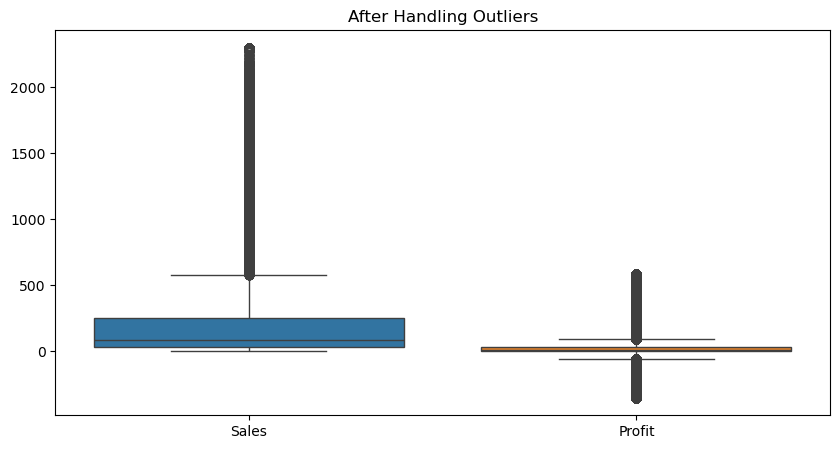

In [28]:
print(df_fixed[['Sales', 'Profit', 'Discount']].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_fixed[['Sales', 'Profit']])
plt.title("After Handling Outliers")
plt.show()

<h1>5. Convert date columns</h1>

In [35]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

<h1>6. Feature Engineering (Date-based)</h1>

In [36]:
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day
df['Order_Weekday'] = df['Order Date'].dt.dayofweek
df['Order_Is_Weekend'] = df['Order_Weekday'].isin([5,6]).astype(int)
df['Order_Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order_Quarter'] = df['Order Date'].dt.quarter

df['Ship_Year'] = df['Ship Date'].dt.year
df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Day'] = df['Ship Date'].dt.day
df['Ship_Weekday'] = df['Ship Date'].dt.dayofweek
df['Ship_Is_Weekend'] = df['Ship_Weekday'].isin([5,6]).astype(int)
df['Ship_Week'] = df['Ship Date'].dt.isocalendar().week.astype(int)
df['Ship_Quarter'] = df['Ship Date'].dt.quarter

# Shipping days difference
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

<h1>7. Label Encoding</h1>

In [31]:
#['Critical' 'Medium' 'High' 'Low']

priority_mapping = {
    'Critical': 4,
    'High': 3,
    'Medium': 2,
    'Low': 1
}

df['Order Priority'] = df['Order Priority'].map(priority_mapping)

<h1>8. One-Hot Encoding</h1>

In [32]:
one_hot_cols = ['Country', 'Region' , 'Market', 'Category', 'Sub-Category', 'Ship Mode']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

<h1>9. Standard Scaling for numerical columns</h1>

In [37]:
scale_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Shipping_Days']
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [40]:
df.head()

,Order Date,Ship Date,Segment,Product ID,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,...,Order_Week,Order_Quarter,Ship_Year,Ship_Month,Ship_Day,Ship_Weekday,Ship_Is_Weekend,Ship_Week,Ship_Quarter,Shipping_Days
0,2012-07-31,2012-07-31,Consumer,TEC-AC-10003033,Plantronics CS510 - Over-the-Head monaural Wir...,0.102006,0.461538,0.000000,0.490812,1.000000,...,0.588235,0.666667,0.25,0.545455,1.000000,0.166667,0.0,0.588235,0.666667,0.000000
1,2013-02-05,2013-02-07,Corporate,FUR-CH-10003950,"Novimex Executive Leather Armchair, Black",0.163837,0.615385,0.117647,0.420749,0.989353,...,0.098039,0.000000,0.50,0.090909,0.200000,0.500000,0.0,0.098039,0.000000,0.285714
2,2013-10-17,2013-10-18,Consumer,TEC-PH-10004664,"Nokia Smart Phone, with Caller ID",0.228586,0.615385,0.117647,0.501331,0.980633,...,0.803922,1.000000,0.50,0.818182,0.566667,0.666667,0.0,0.803922,1.000000,0.142857
3,2013-01-28,2013-01-30,Home Office,TEC-PH-10004583,"Motorola Smart Phone, Cordless",0.127753,0.307692,0.117647,0.433564,0.974924,...,0.078431,0.000000,0.50,0.000000,0.966667,0.333333,0.0,0.078431,0.000000,0.285714
4,2013-11-05,2013-11-06,Consumer,TEC-SHA-10000501,"Sharp Wireless Fax, High-Speed",0.125122,0.538462,0.000000,0.460768,0.967298,...,0.862745,1.000000,0.50,0.909091,0.166667,0.333333,0.0,0.862745,1.000000,0.142857


<h1>10. Final check</h1>

In [43]:
print("\nData types:")
print(df.dtypes.head(15))



Data types:
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Segment                      object
Product ID                   object
Product Name                 object
Sales                       float64
Quantity                    float64
Discount                    float64
Profit                      float64
Shipping Cost               float64
Order Priority                int64
Country_Albania                bool
Country_Algeria                bool
Country_Angola                 bool
Country_Argentina              bool
dtype: object


In [45]:
df.head()

,Order Date,Ship Date,Segment,Product ID,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,...,Order_Week,Order_Quarter,Ship_Year,Ship_Month,Ship_Day,Ship_Weekday,Ship_Is_Weekend,Ship_Week,Ship_Quarter,Shipping_Days
0,2012-07-31,2012-07-31,Consumer,TEC-AC-10003033,Plantronics CS510 - Over-the-Head monaural Wir...,0.102006,0.461538,0.000000,0.490812,1.000000,...,0.588235,0.666667,0.25,0.545455,1.000000,0.166667,0.0,0.588235,0.666667,0.000000
1,2013-02-05,2013-02-07,Corporate,FUR-CH-10003950,"Novimex Executive Leather Armchair, Black",0.163837,0.615385,0.117647,0.420749,0.989353,...,0.098039,0.000000,0.50,0.090909,0.200000,0.500000,0.0,0.098039,0.000000,0.285714
2,2013-10-17,2013-10-18,Consumer,TEC-PH-10004664,"Nokia Smart Phone, with Caller ID",0.228586,0.615385,0.117647,0.501331,0.980633,...,0.803922,1.000000,0.50,0.818182,0.566667,0.666667,0.0,0.803922,1.000000,0.142857
3,2013-01-28,2013-01-30,Home Office,TEC-PH-10004583,"Motorola Smart Phone, Cordless",0.127753,0.307692,0.117647,0.433564,0.974924,...,0.078431,0.000000,0.50,0.000000,0.966667,0.333333,0.0,0.078431,0.000000,0.285714
4,2013-11-05,2013-11-06,Consumer,TEC-SHA-10000501,"Sharp Wireless Fax, High-Speed",0.125122,0.538462,0.000000,0.460768,0.967298,...,0.862745,1.000000,0.50,0.909091,0.166667,0.333333,0.0,0.862745,1.000000,0.142857
